In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
import keras
#from tensorflow.keras import layers, models, optimizers
from math import pi

In [ ]:
def add_noise_ddpm(x):
  """
  Добавляет шум к данным согласно стандартной формуле DDPM.

  Args:
    x: Входные данные (например, изображение).

  Returns:
    Кортеж из двух элементов:
    1. Зашумленные данные и время.
    2. Шум.
  """
  # 1. Генерируем случайное время 't' (скаляр от 0 до 1).
  time = tf.random.uniform([], 0, 1)

  # 2. Определяем расписание шума. Например, линейное.
  # Это значения, которые определяют, как быстро добавляется шум.
  beta_start = 0.0001
  beta_end = 0.02
  
  # Вычисляем бета для данного времени 't'.
  beta_t = beta_start + time * (beta_end - beta_start)
  
  # 3. Вычисляем alpha_bar_t.
  # Здесь мы используем простую формулу для alpha_bar_t
  # на основе beta_t.
  alpha_bar_t = 1.0 - beta_t
  
  # 4. Генерируем нормальный шум того же размера, что и данные.
  noise = tf.random.normal(tf.shape(x))
  
  # 5. Применяем формулу DDPM.
  # Мы используем sqrt(alpha_bar_t) для чистых данных
  # и sqrt(1 - alpha_bar_t) для шума.
  noised_x = tf.sqrt(alpha_bar_t) * x + tf.sqrt(1 - alpha_bar_t) * noise

  # 6. Объединяем зашумленные данные и время в один вектор.
  # Это нужно, чтобы передать их в один входной слой модели.
  flattened_x = tf.reshape(noised_x, [-1])
  time_tensor = tf.reshape(time, [1])
  output_data = tf.concat([flattened_x, time_tensor], axis=-1)

  # 7. Возвращаем объединенный тензор и шум.
  # Модель будет учиться предсказывать 'noise' на основе 'output_data'.
  return output_data, noise


In [4]:
def generate_dataset(N, complexity = 3):
    angle = tf.random.uniform((N, ), 0, complexity)
    r = angle/complexity
    return tf.stack((r*tf.cos(angle*2*pi ), r*tf.sin(angle*2*pi )), -1)

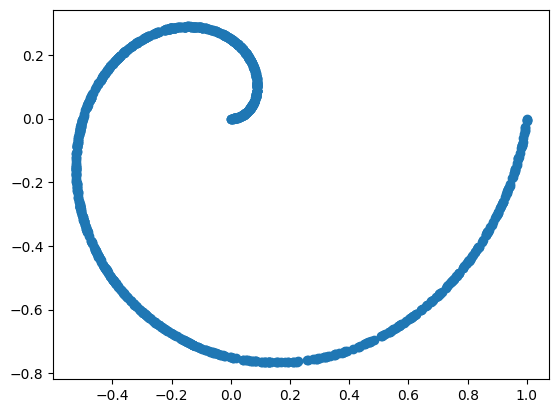

In [5]:
d = generate_dataset(1000, 1)
plt.scatter(d[:, 0], d[:, 1])
plt.show()

In [6]:
data = tf.data.Dataset.from_tensor_slices(d)
data = data.map(add_noise_ddpm)
data = data.batch(32)

In [7]:
def get_model():
    x = keras.Input(shape=(3,))
    y = layers.Dense(16, activation='relu')(x)
    y = layers.Dense(16, activation='relu')(y)
    y = layers.Dense(16, activation='relu')(y)
    y = layers.Dense(16, activation='relu')(y)
    y = layers.Dense(2, activation='linear')(y)
    model = keras.Model(inputs=x, outputs=y)
    return model

In [8]:
model = get_model()
model.build(3)
model.compile(optimizer='adam', loss='mae')


In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 914 (3.57 KB)

 Trainable params: 914 (3.57 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.fit(data, epochs=500)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5497
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5650 
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5529 
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5194 
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5319 
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5176 
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5291 
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5463 
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5301 
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5227 
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5313 
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5432 
Epoch 13/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5362 
Epoch 14/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5336 
Epoch 15/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss

In [19]:
def generate_new_data(model, num_samples=1000, steps=100):
    dt = 1 / steps
    # Generate random input data
    state = tf.random.normal((num_samples, 2))
    # adding time dimension
    # Get the model's predictions
    for step in range(steps):
        t = step * dt
        model_input = tf.concat([state, tf.fill((num_samples, 1), t)], axis=-1)

        state = state - model(model_input)*dt
    return state

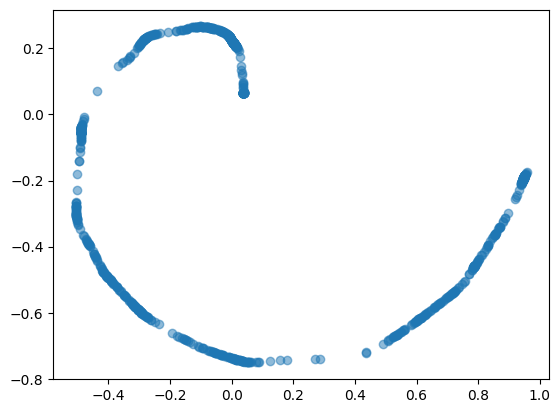

In [20]:
generated_data = generate_new_data(model, num_samples=1000, steps = 100)
plt.scatter(generated_data[:, 0], generated_data[:, 1], alpha=0.5)
plt.show()

In [21]:
def generate_new_data_ddim(model, num_samples=1000, steps=1000):
    # Начинаем с шума
    state = tf.random.normal((num_samples, 2))
    
    # Определяем расписание шума
    beta_start = 0.0001
    beta_end = 0.02
    
    # Создаём массив alpha_bar_t для всех шагов
    alpha_bar = 1.0 - (beta_start + tf.linspace(0.0, 1.0, steps) * (beta_end - beta_start))

    # Итерация от t=steps до t=1
    for i in range(steps, 0, -1):
        t = i / steps
        t_prev = (i - 1) / steps
        
        # Вычисляем коэффициенты
        alpha_bar_t = alpha_bar[i-1]
        alpha_bar_t_prev = alpha_bar[i-2] if i > 1 else 1.0
        
        # Формируем вход для модели
        model_input = tf.concat([state, tf.fill((num_samples, 1), t)], axis=-1)
        
        # Модель предсказывает шум
        predicted_noise = model(model_input)
        
        # Вычисляем предсказание чистого изображения (x_0_predicted)
        x_0_predicted = (state - tf.sqrt(1 - alpha_bar_t) * predicted_noise) / tf.sqrt(alpha_bar_t)
        
        # Вычисляем новое состояние (следующий шаг в обратном процессе)
        state = tf.sqrt(alpha_bar_t_prev) * x_0_predicted + tf.sqrt(1 - alpha_bar_t_prev) * predicted_noise

    return state


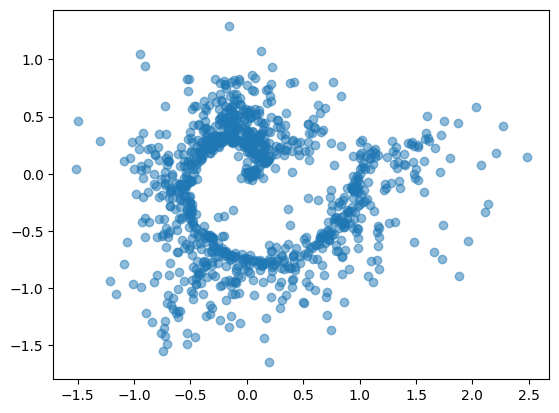

In [22]:
generated_data = generate_new_data_ddim(model, num_samples=1000, steps = 100)
plt.scatter(generated_data[:, 0], generated_data[:, 1], alpha=0.5)
plt.show()